In [1]:
import numpy as np
import os 
from tqdm import tqdm
import matplotlib.pyplot as plt
import sys
sys.path.append('../')
import src.learning as lrn
%load_ext autoreload
%matplotlib widget

# Training and Testing Data Analysis

In [2]:
base_dir = "../saved/controllable_set/reachset_train/20231115-025054"
data_random = np.load(os.path.join(base_dir, "data_random.npy"))
data_structured = np.load(os.path.join(base_dir, "data_structured.npy"))
reachset = np.vstack((data_structured, data_random))

print(f"Random data shape: {data_random.shape}")
print(f"Structured data shape: {data_structured.shape}")
print(f"Reachset shape: {reachset.shape}")

Random data shape: (68140, 11)
Structured data shape: (20585, 11)
Reachset shape: (88725, 11)


# Train NN

### Normalize dataset

In [3]:
xmin_, xmax_, ymax_, x_ymax_ = lrn.transform_reachsetparam(
    xmin=reachset[:, 5], 
    xmax=reachset[:, 7], 
    ymax=reachset[:, 10], 
    x_ymax=reachset[:, 9], 
    alt=reachset[:, 0],
    )

# print max and min for xmin_, xmax_, ymax_, x_ymax_
print(f"xmin_: [{np.min(xmin_):.2f}, {np.max(xmin_):.2f}]")
print(f"xmax_: [{np.min(xmax_):.2f}, {np.max(xmax_):.2f}]")
print(f"ymax_: [{np.min(ymax_):.2f}, {np.max(ymax_):.2f}]")
print(f"x_ymax_: [{np.min(x_ymax_):.2f}, {np.max(x_ymax_):.2f}]")

alt_, vx_, vz_, z_, tgo_ = lrn.transform_ic(
    alt=reachset[:, 0],
    vx=reachset[:, 1],
    vz=reachset[:, 2],
    z=np.log(reachset[:, 3]),
    tgo=reachset[:, 4],
    )

# print max and min for alt_, vx_, vz_, z_, tgo_
print(f"alt_: [{np.min(alt_):.2f}, {np.max(alt_):.2f}]")
print(f"vx_: [{np.min(vx_):.2f}, {np.max(vx_):.2f}]")
print(f"vz_: [{np.min(vz_):.2f}, {np.max(vz_):.2f}]")
print(f"z_: [{np.min(z_):.2f}, {np.max(z_):.2f}]")
print(f"tgo_: [{np.min(tgo_):.2f}, {np.max(tgo_):.2f}]")

xmin_: [0.65, 0.98]
xmax_: [0.02, 0.98]
ymax_: [0.01, 0.95]
x_ymax_: [0.50, 0.98]
alt_: [0.01, 0.85]
vx_: [0.00, 0.56]
vz_: [0.00, 0.93]
z_: [0.11, 1.00]
tgo_: [0.05, 0.75]


### Prep dataset

In [4]:
import torch
import datetime
from torch.utils.data import DataLoader, random_split

# define hyperparameters
train_data_rate = 0.95
batch_size = 1024

# create dataset and dataloader
dataset = lrn.ReachsetDataset(reachset=reachset)
n_data = len(dataset)
train_size = int(train_data_rate * n_data)
test_size = n_data - train_size
train_set, test_set = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=True)

In [5]:
def train_reach(model, train_loader, test_loader, criterion, n_epochs=100, lr=1e-3, device="cpu", print_every=None):
    # define optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # move model to device
    model.to(device)

    # training loop
    train_loss = []
    test_loss = []
    for epoch in tqdm(range(n_epochs)):
        # train
        model.train()
        train_loss_epoch = 0
        for i, (_, x, y) in enumerate(train_loader):
            # move batch to device
            x = x.to(device)
            y = y.to(device)

            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            y_hat = model(x)
            loss = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
            if print_every is not None:
                if i % print_every == 0:
                    print(f"Epoch {epoch + 1} | Batch {i} | Loss: {loss.item():.4f}")

            # update loss
            train_loss_epoch += loss.item()

        # test
        model.eval()
        test_loss_epoch = 0
        with torch.no_grad():
            for _, x, y in test_loader:
                # move batch to device
                x = x.to(device)
                y = y.to(device)

                # forward
                y_hat = model(x)
                loss = criterion(y_hat, y)

                # update loss
                test_loss_epoch += loss.item()

        #print(f"Epoch {epoch + 1} | Train loss: {train_loss_epoch / len(train_loader):.4f} | Test loss: {test_loss_epoch / len(test_loader):.4f}")

        # update loss
        train_loss.append(train_loss_epoch / len(train_loader))
        test_loss.append(test_loss_epoch / len(test_loader))

    return train_loss, test_loss, model

def save_model(model, model_name, train_loss, test_loss, hidden_layers, lr, batch_size, train_data_rate, device, out_dir):
    # save model
    torch.save(model.state_dict(), os.path.join(out_dir, model_name))

    # save training and test loss
    np.save(os.path.join(out_dir, "train_loss.npy"), train_loss)
    np.save(os.path.join(out_dir, "test_loss.npy"), test_loss)

    # save hyperparameters
    hyperparameters = {
        "hidden_layers": hidden_layers,
        "lr": lr,
        "batch_size": batch_size,
        "train_data_rate": train_data_rate,
        "device": device,
    }
    np.save(os.path.join(out_dir, "hyperparameters.npy"), hyperparameters)

def plot_loss(train_loss, test_loss):
    fig, ax = plt.subplots()
    ax.plot(train_loss, label="Train loss")
    ax.plot(test_loss, label="Test loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_yscale("log")
    ax.grid()
    ax.legend()
    plt.show()

In [12]:
now = datetime.datetime.now()
now = now.strftime("%Y%m%d-%H%M%S")
out_dir = os.path.join(base_dir, f"models_{now}")
os.makedirs(out_dir)

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

lr = 1e-4
n_epochs = 1000
hidden_layers = [256, 256, 256]
model = lrn.NeuralReach(hidden_layers=hidden_layers)
criterion = torch.nn.MSELoss()

train_loss, test_loss, model = train_reach(model, train_loader, test_loader, criterion, n_epochs=n_epochs, lr=lr, device=device)

model_dir = os.path.join(out_dir, "mlp_reach")
os.makedirs(model_dir)
save_model(model, "mlp_reach.pt", train_loss, test_loss, hidden_layers, lr, batch_size, train_data_rate, device, model_dir)

100%|██████████| 1000/1000 [1:54:13<00:00,  6.85s/it] 


In [25]:
out_dir = "../saved/controllable_set/reachset_train/20231115-025054//models_20240808-162255"

In [28]:
model_dir = os.path.join(out_dir, "mlp_reach")
save_model(model, "mlp_reach.pt", train_loss, test_loss, hidden_layers, lr, batch_size, train_data_rate, device, model_dir)
# save train and test dataset
np.save(os.path.join(model_dir, "train_set.npy"), train_set.dataset.reachset)
np.save(os.path.join(model_dir, "test_set.npy"), test_set.dataset.reachset)

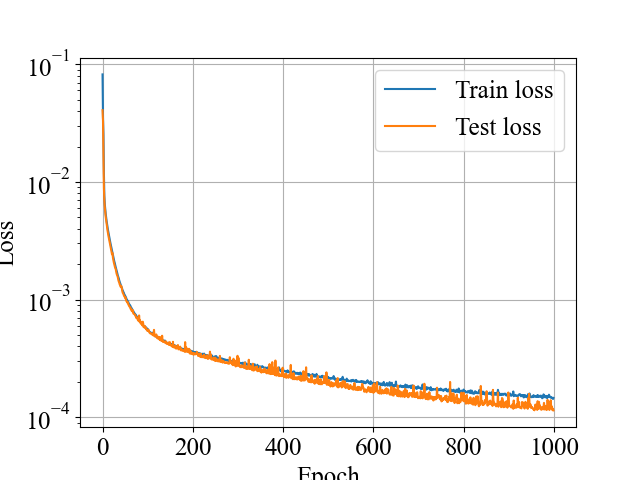

In [15]:
plot_loss(train_loss, test_loss)

# Analyze NN-Reach Model

### Qualitative Analysis

In [16]:

model.eval()
test_loader = DataLoader(test_set, batch_size=1, shuffle=True)
n_max = 10000
n_test = min(n_max, len(test_loader))
x_mat = np.zeros((n_test, 5))
y_mat = np.zeros((n_test, 4))
y_hat_mat = np.zeros((n_test, 4))
error_mat = np.zeros((n_test, 4))
with torch.no_grad():
    for i, (_, x, y) in enumerate(tqdm(test_loader)):
        if i >= n_test:
            break
        
        # move batch to device
        x = x.to(device)
        y = y.to(device)

        # forward
        y_hat = model(x)

        # scale back
        alt, vx, vz, z, tgo = lrn.inverse_transform_ic(alt_=x[0, 0], vx_=x[0, 1], vz_=x[0, 2], z_=x[0, 3], tgo_=x[0, 4])
        y_hat = lrn.inverse_transform_reachsetparam(xmin_=y_hat[0, 0], xmax_=y_hat[0, 1], ymax_=y_hat[0, 2], x_ymax_=y_hat[0, 3], alt=alt)
        y = lrn.inverse_transform_reachsetparam(xmin_=y[0, 0], xmax_=y[0, 1], ymax_=y[0, 2], x_ymax_=y[0, 3], alt=alt)

        # save 
        x_mat[i, :] = [alt, vx, vz, z, tgo]
        y_mat[i, :] = np.array(y)
        y_hat_mat[i, :] = np.array(y_hat)
        error_mat[i, :] = np.array(y_hat) - np.array(y)

100%|██████████| 4437/4437 [00:03<00:00, 1351.56it/s]


xmin: mean error = 1.711, std error = 3.537
xmax: mean error = 0.320, std error = 0.486
ymax: mean error = 0.761, std error = 1.744
x_ymax: mean error = 1.191, std error = 2.137
xmin: mean error = 0.694 %, std error = 1.198 %
xmax: mean error = 0.130 %, std error = 0.180 %
ymax: mean error = 0.324 %, std error = 0.677 %
x_ymax: mean error = 0.489 %, std error = 0.764 %


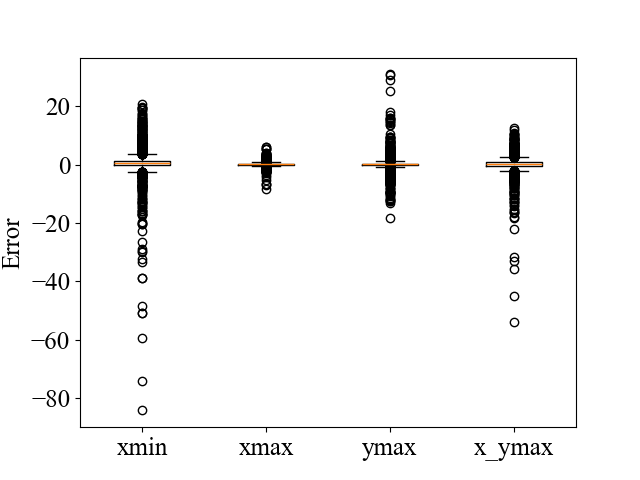

In [19]:
# print mean and std of error for each column
param_names = ["xmin", "xmax", "ymax", "x_ymax"]
for i, param_name in enumerate(param_names):
    mean_error = np.mean(np.abs(error_mat[:, i]))
    std_error = np.std(np.abs(error_mat[:, i]))
    print(f"{param_name}: mean error = {mean_error:.3f}, std error = {std_error:.3f}")

# print mean and std of error for each column
# but this time calc error as relative error
# load picked lander
import pickle
with open('../saved/controllable_set/lander.pkl', 'rb') as f:
    lander = pickle.load(f)

param_names = ["xmin", "xmax", "ymax", "x_ymax"]
x_scale = np.abs((y_mat[:, 0] - y_mat[:, 1]))
y_scale = np.abs(y_mat[:, 2])
#scales = [x_scale, x_scale, y_scale, x_scale]
for i, param_name in enumerate(param_names):
    scale = x_mat[:, 0] * np.tan(lander.fov / 2) * 2
    mean_error = np.mean(np.abs(error_mat[:, i] / scale)) * 100
    std_error = np.std(np.abs(error_mat[:, i] / scale)) * 100
    print(f"{param_name}: mean error = {mean_error:.3f} %, std error = {std_error:.3f} %")

# plot error; make boxplot for each column
fig, ax = plt.subplots()
ax.boxplot(error_mat)
ax.set_xticklabels(["xmin", "xmax", "ymax", "x_ymax"])
ax.set_ylabel("Error")
plt.show()

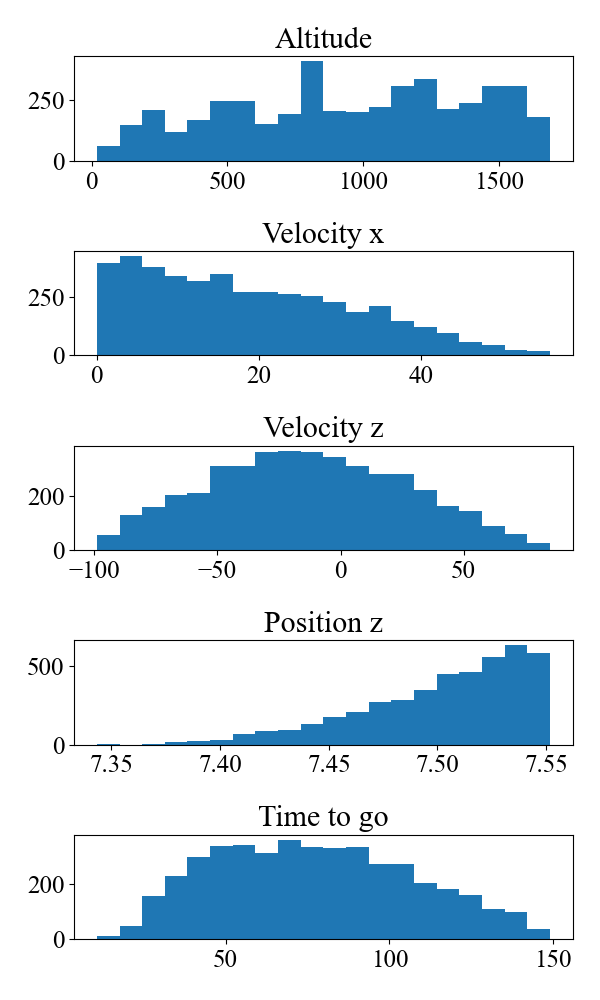

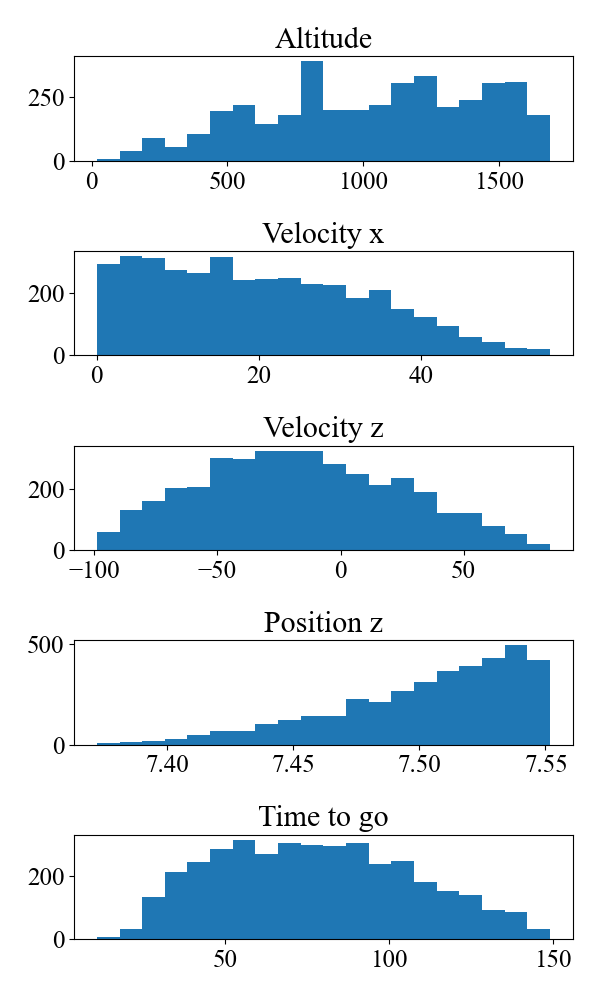

In [47]:
# plot histogram for all data points
# histogram for alt, vx, vz, z, tgo
fig, ax = plt.subplots(5, 1, figsize=(6, 10))
ax[0].hist(x_mat[:, 0], bins=20)
ax[0].set_title("Altitude")
ax[1].hist(x_mat[:, 1], bins=20)
ax[1].set_title("Velocity x")
ax[2].hist(x_mat[:, 2], bins=20)
ax[2].set_title("Velocity z")
ax[3].hist(x_mat[:, 3], bins=20)
ax[3].set_title("Position z")
ax[4].hist(x_mat[:, 4], bins=20)
ax[4].set_title("Time to go")
plt.tight_layout()
plt.show()


# plot histogram for data points where error is greater than 1
# histogram for alt, vx, vz, z, tgo
error_abs = np.abs(error_mat)
error_sum = np.sum(error_abs, axis=1)
idx = error_sum > 1
fig, ax = plt.subplots(5, 1, figsize=(6, 10))
ax[0].hist(x_mat[idx, 0], bins=20)
ax[0].set_title("Altitude")
ax[1].hist(x_mat[idx, 1], bins=20)
ax[1].set_title("Velocity x")
ax[2].hist(x_mat[idx, 2], bins=20)
ax[2].set_title("Velocity z")
ax[3].hist(x_mat[idx, 3], bins=20)
ax[3].set_title("Position z")
ax[4].hist(x_mat[idx, 4], bins=20)
ax[4].set_title("Time to go")
plt.tight_layout()
plt.show()


In [34]:
# visualize sample
sample_id = 0
alt, vx, vz, z, tgo = x_mat[sample_id, :]
y = y_mat[sample_id, :]
y_hat = y_hat_mat[sample_id, :]
error = error_mat[sample_id, :]

print(f"alt: {alt:.2f}, vx: {vx:.2f}, vz: {vz:.2f}, z: {z:.2f}, tgo: {tgo:.2f}")
print(f"y: {y}")
print(f"y_hat: {y_hat}")
print(f"error: {error}")


alt: 401.25, vx: 11.21, vz: -24.58, z: 7.47, tgo: 21.30
y: [-27.6270369   52.82579578  51.5651058    9.06640623]
y_hat: [-26.03101516  52.94039513  51.54676711   7.58187741]
error: [ 1.59602175  0.11459936 -0.0183387  -1.48452881]
